In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from numpy import unique
from numpy import reshape
from keras.models import Sequential
from keras.layers import Conv1D, Conv2D, Dense, Dropout, BatchNormalization, Flatten, MaxPooling2D, Activation
from keras import utils
from keras.datasets import mnist
from numpy import argmax
from PIL import Image
from numpy import asarray

In [20]:
tf.random.set_seed(42)

In [21]:
hand = mnist.load_data()

In [22]:
hand[0]

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],

In [23]:
(X_train, y_train), (X_test, y_test) = hand

In [24]:
np.set_printoptions(edgeitems=3)
np.core.arrayprint._line_width = 180000

In [25]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [26]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [27]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

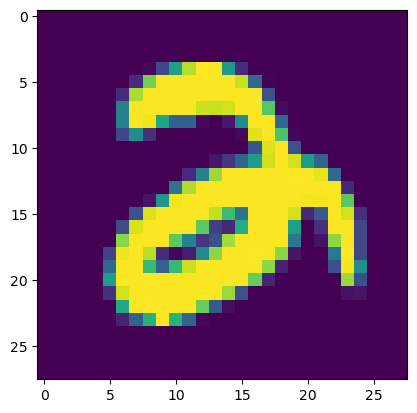

In [10]:
plt.imshow(X_train[28335])

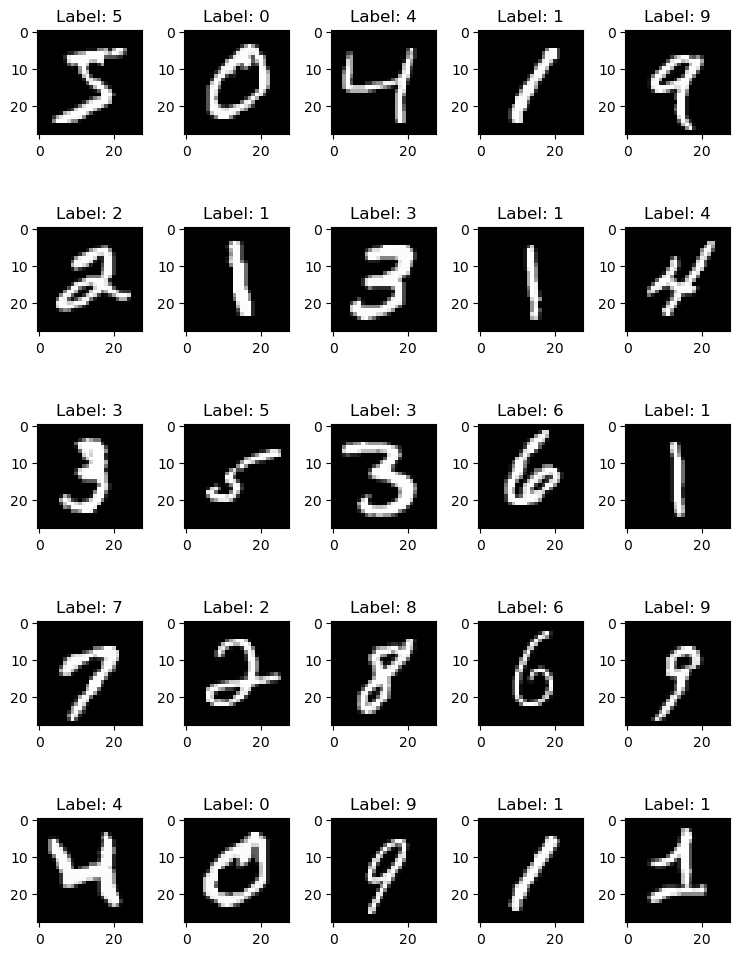

In [11]:
num = 25
images = X_train[:num]
labels = y_train[:num]

num_row = 5
num_col = 5
# plot images
fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
    ax = axes[i//num_col, i%num_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title('Label: {}'.format(labels[i]))
plt.tight_layout()
plt.show()

In [28]:
# 5. Preprocess input data
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

In [29]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [30]:
X_train /= 255
X_test /= 255

In [31]:
# 6. Preprocess class labels
Y_train = utils.to_categorical(y_train, 10)
Y_test = utils.to_categorical(y_test, 10)

In [32]:
Y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [33]:
for label in range(10):
    one_hot = (Y_train[label]).astype(np.int32)
    print("label: ", label, " in one-hot representation: ", one_hot)

label:  0  in one-hot representation:  [0 0 0 0 0 1 0 0 0 0]
label:  1  in one-hot representation:  [1 0 0 0 0 0 0 0 0 0]
label:  2  in one-hot representation:  [0 0 0 0 1 0 0 0 0 0]
label:  3  in one-hot representation:  [0 1 0 0 0 0 0 0 0 0]
label:  4  in one-hot representation:  [0 0 0 0 0 0 0 0 0 1]
label:  5  in one-hot representation:  [0 0 1 0 0 0 0 0 0 0]
label:  6  in one-hot representation:  [0 1 0 0 0 0 0 0 0 0]
label:  7  in one-hot representation:  [0 0 0 1 0 0 0 0 0 0]
label:  8  in one-hot representation:  [0 1 0 0 0 0 0 0 0 0]
label:  9  in one-hot representation:  [0 0 0 0 1 0 0 0 0 0]


In [34]:
epochs = 30
batch_size = 16
n_hidden = 32

#timesteps = len(X_train[0])
#input_dim = len(X_train[0][0])
#n_classes = _count_classes(Y_train)

# 7. Define model architecture
model = Sequential()
 
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
 
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))
 
# 8. Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [35]:
# 9. Fit model on training data
model.fit(X_train, Y_train, batch_size=32, epochs=10, verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 92s 49ms/step - accuracy: 0.8722 - loss: 0.4016
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 102s 54ms/step - accuracy: 0.9735 - loss: 0.0909
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 109s 58ms/step - accuracy: 0.9791 - loss: 0.0698
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 91s 49ms/step - accuracy: 0.9830 - loss: 0.0556
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 108s 58ms/step - accuracy: 0.9857 - loss: 0.0463
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 122s 65ms/step - accuracy: 0.9883 - loss: 0.0399
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 133s 60ms/step - accuracy: 0.9887 - loss: 0.0365
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 125s 66ms/step - accuracy: 0.9893 - loss: 0.0351
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 121s 65ms/step - accuracy: 0.9899 - loss: 0.0324
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 113s 60ms/step - accuracy: 0.9909 - loss: 0.0277


In [36]:
# 10. Evaluate model on test data
score = model.evaluate(X_test, Y_test, verbose=2)

313/313 - 3s - 8ms/step - accuracy: 0.9915 - loss: 0.0322


In [37]:
#predict first 4 images in the test set
model.predict(X_test[:4])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


array([[9.13680041e-16, 4.09680727e-11, 1.94064764e-10, 3.04955927e-09,
        8.40061202e-13, 3.54586423e-14, 2.04076236e-19, 1.00000000e+00,
        6.46288058e-12, 3.77483786e-08],
       [1.07580795e-12, 1.58823954e-10, 1.00000000e+00, 3.63199495e-14,
        8.35523608e-19, 6.51880967e-21, 1.14966189e-10, 1.49515824e-17,
        2.62862572e-15, 1.89223394e-19],
       [3.75242684e-11, 9.99999642e-01, 1.38508716e-08, 9.96141104e-12,
        1.47709244e-07, 8.85387375e-10, 8.52308091e-08, 6.13967046e-08,
        1.94794625e-09, 8.76640496e-11],
       [1.00000000e+00, 1.20639835e-11, 1.75841893e-11, 5.03825009e-13,
        7.66651282e-14, 1.36201059e-11, 5.66161447e-08, 6.67227124e-12,
        9.88348361e-11, 1.81355397e-09]], dtype=float32)

In [38]:
sumarray = np.sum(model.predict(X_test[:4]), axis=1)
sumarray

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


array([1.        , 1.        , 0.99999994, 1.        ], dtype=float32)

In [39]:
#actual results for first 4 images in test set
y_test[:4]

array([7, 2, 1, 0], dtype=uint8)

In [40]:
test_predictions = model.predict(X_test)
cm = confusion_matrix(y_test, np.argmax(test_predictions,axis=1))
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step
[[ 975    0    0    0    0    0    3    0    1    1]
 [   0 1130    2    0    0    1    1    1    0    0]
 [   1    1 1025    0    0    0    0    4    1    0]
 [   0    0    1 1005    0    3    0    0    1    0]
 [   0    0    1    0  972    0    1    0    2    6]
 [   0    0    0    3    0  888    1    0    0    0]
 [   4    3    0    0    1    5  944    0    1    0]
 [   0    1    5    1    0    0    0 1017    1    3]
 [   2    1    3    1    0    0    0    1  964    2]
 [   1    0    0    0    3    2    0    1    7  995]]


In [ ]:
path = r"~/Documents/Career Foundry/specialization/Data Sets/Unsupervised/numbers"

In [128]:
img = Image.open(os.path.join(path, '9.png')) #<--FILL IN THIS VALUE!
print(img.format)
print(img.size)
print(img.mode)

PNG
(28, 28)
L


In [129]:
img2 = img.convert("P")
img2

In [130]:
testimg = asarray(img2)

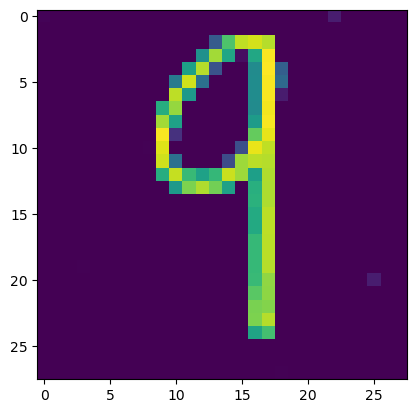

In [131]:
plt.imshow(testimg)

In [94]:
print(testimg.shape)

(28, 28)


In [133]:
testimg = testimg.reshape(1, 28, 28, 1)

In [89]:
# predict the class
predict_value = model.predict(testimg)
digit = argmax(predict_value)
print(f"Actual Number: 0")
print(f"Predicted Number: {digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Actual Number: 0
Predicted Number: 0


In [96]:
# predict the class
predict_value = model.predict(testimg)
digit = argmax(predict_value)
print(f"Actual Number: 1")
print(f"Predicted Number: {digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Actual Number: 1
Predicted Number: 1


In [103]:
# predict the class
predict_value = model.predict(testimg)
digit = argmax(predict_value)
print(f"Actual Number: 2")
print(f"Predicted Number: {digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Actual Number: 2
Predicted Number: 2


In [109]:
# predict the class
predict_value = model.predict(testimg)
digit = argmax(predict_value)
print(f"Actual Number: 3")
print(f"Predicted Number: {digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Actual Number: 3
Predicted Number: 3


In [115]:
# predict the class
predict_value = model.predict(testimg)
digit = argmax(predict_value)
print(f"Actual Number: 4")
print(f"Predicted Number: {digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Actual Number: 4
Predicted Number: 4


In [121]:
# predict the class
predict_value = model.predict(testimg)
digit = argmax(predict_value)
print(f"Actual Number: 5")
print(f"Predicted Number: {digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Actual Number: 5
Predicted Number: 5


In [127]:
# predict the class
predict_value = model.predict(testimg)
digit = argmax(predict_value)
print(f"Actual Number: 6")
print(f"Predicted Number: {digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Actual Number: 6
Predicted Number: 6


In [82]:
# predict the class
predict_value = model.predict(testimg)
digit = argmax(predict_value)
print(f"Actual Number: 7")
print(f"Predicted Number: {digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Actual Number: 7
Predicted Number: 2


In [70]:
# predict the class
predict_value = model.predict(testimg)
digit = argmax(predict_value)
print(f"Actual Number: 8")
print(f"Predicted Number: {digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Actual Number: 8
Predicted Number: 8


In [134]:
# predict the class
predict_value = model.predict(testimg)
digit = argmax(predict_value)
print(f"Actual Number: 9")
print(f"Predicted Number: {digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Actual Number: 9
Predicted Number: 4
